# Mario Input Autoencoder: a binary code at the Shannon bound

Shannon's source coding theorem sets a hard floor on compression: a source with
entropy `H` bits per event cannot be encoded losslessly in fewer than `H` bits per
event. That floor applies to every encoder, learned ones included, so it makes a
concrete and falsifiable prediction about what a trained latent space should look
like once its capacity is pinned to exactly `H`. This notebook tests that
prediction on a neural autoencoder that optimizes nothing but reconstruction error
and is given no knowledge of information theory.

The test bed is Super Mario 64 TAS controller input. Real `.m64` replays are
parsed into six mutually exclusive categories (`Directional, A, B, Z/L/R, Start,
No Input`), each frame is expanded into a stream of one-hot events, and that
stream is sliced into 100-event windows. Its empirical entropy measures 2.4683
bits per event, against 2.585 for a uniform six-way source, so a 100-event window
carries 246.83 bits on average. The latent is fixed at 247 bits to match. That
leaves the models exactly the theoretical minimum and no slack, which is the point
of the exercise: given spare capacity, a code could reconstruct well while leaving
bits dead or redundant, and any claim to have compressed to `H` would be empty.

Training runs on 500k windows sampled i.i.d. from the empirical category
marginals rather than on the raw replay stream, and this is central to the design
rather than a convenience. Sampling i.i.d. fixes the true entropy of the training
distribution at exactly 2.4683 bits per event, giving the experiment a target that
is computed rather than estimated. The real stream carries heavy temporal
structure, with inputs held for 100+ frames and long idle waits, which pushes its
true entropy lower by an unknown margin and would leave the central measurement
without a reference point. Discarding the runs buys an exact bound.

Three models are compared at that latent size. Two are binarizing autoencoders,
identical in architecture and parameter count and differing only in how they
binarize: `AnnealingAutoencoder` applies `sigmoid(β · logits)` with `β` hardened
toward a step across epochs, while `STEAutoencoder` applies a hard threshold with
a straight-through gradient. The third is a lookup memoriser that learns nothing,
assigning every window in the real dataset a fixed random code and encoding
anything unseen to zeros. It makes the standard objection to any autoencoder
result, that the network merely memorized a `sample ↔ bitstring` table, literal
enough to measure against. All three are evaluated on reconstruction, latent
correlation, order sensitivity, and per-bit entropy.

| | Annealing | STE | Control (lookup) |
|---|---|---|---|
| Mean per-bit entropy (of max 1.0) | 0.984 | 0.987 | 0.000 |
| Bits that vary at all | 247/247 | 247/247 | 0/247 |
| Mean pairwise \|r\| between bits | 0.029 | 0.014 | n/a |
| Bit pairs with \|r\| > 0.5 | 0 of 30,381 | 0 of 30,381 | n/a |
| Reconstruction, macro F1 | 0.973 | 0.767 | 0.048 |
| Shuffle / baseline Hamming ratio | 0.99 | 0.99 | n/a |

Both trained models produce codes whose bits resemble fair, independent coin
flips: per-bit entropy sits at roughly 0.98 of the maximum, every one of the 247
bits varies, and not a single pair correlates above `|r| = 0.5`. That is the
signature theory predicts for a code sitting at its entropy bound, and nothing in
the loss function asked for it. The order-sensitivity test in §8.3 establishes
that those bits encode the ordered sequence rather than a summary of it, which is
what makes the entropy result meaningful in the first place. Annealing
reconstructs at 0.973 macro F1 against STE's 0.767, and the lookup control
collapses to 0.048 on windows it has never seen.

> Runs top-to-bottom on Colab (models persist to Drive) or locally. See §9 for the
> conclusions and the open questions that bound them.

## 1. Setup & configuration

Install dependencies, import everything, choose whether to reuse saved weights,
and, on Colab, mount Drive so trained models survive across sessions.

Two flags control persistence. `SAVE_MODELS` decides whether weights are written
to and read from disk at all, and `FORCE_RETRAIN` decides whether existing
weights are ignored. Their combinations behave as follows.

| `SAVE_MODELS` | `FORCE_RETRAIN` | Behavior |
|---|---|---|
| `False` | `False` | Always retrain. Weights are never saved or loaded. |
| `True` | `False` | Load saved weights if they exist, otherwise train and save. This is the default. |
| `True` | `True` | Always retrain from scratch, then save the new weights. |
| `False` | `True` | Always retrain from scratch. Weights are never saved. |

Training the two models takes roughly 50 epochs each over 400k windows, so the
default reuses saved weights when they are present.

In [1]:
import sys
if "google.colab" in sys.modules:
    !pip install requests torch numpy matplotlib scipy -q
else:
    !~/.local/bin/uv pip install --python {sys.executable} requests torch numpy matplotlib scipy --quiet

In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
# Collected here so every downstream cell can assume them. Grouped by origin:
# standard library, numerical / ML, plotting.
import struct
import hashlib
from pathlib import Path

import requests
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset

import matplotlib.pyplot as plt

In [3]:

# ── Model persistence config (see the markdown above for the flag matrix) ─────
SAVE_MODELS   = True
FORCE_RETRAIN = False

MODEL_DIR = (
    Path("/content/drive/MyDrive/mario_autoencoder")
    if "google.colab" in sys.modules
    else Path(".")
)

ANNEALING_PATH = MODEL_DIR / "annealing_model.pt"
STE_PATH       = MODEL_DIR / "ste_model.pt"


In [4]:
# ── Mount Google Drive (Colab only) ──────────────────────────────────────────
# Mounts Drive and creates the model directory so .pt files persist across sessions.
# Skip this cell if running locally.
if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive")
    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    print(f"Models will be saved to: {MODEL_DIR}")
else:
    print(f"Running locally — models will be saved to: {MODEL_DIR.resolve()}")

Mounted at /content/drive
Models will be saved to: /content/drive/MyDrive/mario_autoencoder


## 2. Parsing `.m64` replay files

An `.m64` file stores one 4-byte controller sample per frame, holding stick x/y
plus a 16-bit button mask. `parse_m64` collapses each frame's raw buttons into six
mutually exhaustive categories (`Directional, A, B, Z/L/R, Start, No Input`), so a
frame becomes a 6-way multi-hot vector.

This binning is a modeling decision rather than neutral preprocessing. The
categories define the source whose entropy is measured in §4, and that entropy in
turn fixes the latent size in §5, so the choice made here propagates through the
entire experiment.

In [5]:
BUTTON_BITS = [
    0x8000, 0x4000, 0x2000, 0x1000,
    0x0800, 0x0400, 0x0200, 0x0100,
    0x0020, 0x0010, 0x0008, 0x0004, 0x0002, 0x0001,
]

# 6 output categories
CAT_NAMES = ["Directional", "A", "B", "Z/L/R", "Start", "No Input"]
INPUT_DIM  = 6

# Which columns of the 16-col base tensor [stick_x, stick_y, A..CRight] map to each category
#   col 0  = stick_x   col 1  = stick_y
#   col 2  = A         col 3  = B
#   col 4  = Z         col 5  = Start
#   col 6  = DUp       col 7  = DDown    col 8  = DLeft   col 9  = DRight
#   col 10 = L         col 11 = R
#   col 12 = CUp       col 13 = CDown    col 14 = CLeft   col 15 = CRight
CAT_COLS = [
    [0, 1, 6, 7, 8, 9, 12, 13, 14, 15], # Directional (Stick + D-Pad + C-Buttons)
    [2],                                  # A
    [3],                                  # B
    [4, 10, 11],                          # Z/L/R
    [5],                                  # Start
]


def parse_m64(raw: bytes) -> torch.Tensor:
    """Parse .m64 bytes into a (T, 6) binary float32 tensor — one column per category.
    Categories: [Directional, A, B, Z/L/R, Start, No Input]
    """
    version = struct.unpack_from("<I", raw, 0x004)[0]
    data_start = 0x200 if version in (1, 2) else 0x400
    num_samples = struct.unpack_from("<I", raw, 0x018)[0]

    buf = np.frombuffer(
        raw[data_start : data_start + num_samples * 4], dtype=np.uint8
    ).reshape(num_samples, 4)

    y_axis  = buf[:, 0].view(np.int8)
    x_axis  = buf[:, 1].view(np.int8)
    btn_raw = buf[:, 2].astype(np.uint16) * 256 + buf[:, 3].astype(np.uint16)
    buttons = np.stack(
        [(btn_raw & bit).astype(bool) for bit in BUTTON_BITS], axis=1
    ).astype(np.float32)

    stick_x = torch.from_numpy((x_axis != 0).astype(np.float32)).unsqueeze(1)
    stick_y = torch.from_numpy((y_axis != 0).astype(np.float32)).unsqueeze(1)
    btns    = torch.from_numpy(buttons)
    base    = torch.cat([stick_x, stick_y, btns], dim=1)  # (T, 16)

    cat_active = torch.stack(
        [base[:, cols].any(dim=1) for cols in CAT_COLS], dim=1
    ).float()  # (T, 5)

    no_input = (~cat_active.any(dim=1)).unsqueeze(1).float()
    return torch.cat([cat_active, no_input], dim=1)  # (T, 6)


def load_m64(source: str, cache_dir: str = ".") -> torch.Tensor:
    """Load an .m64 from a local path or URL, caching downloads locally."""
    if source.startswith("http://") or source.startswith("https://"):
        cache_path = Path(cache_dir) / Path(source).name
        if not cache_path.exists():
            print(f"Downloading {source} ...")
            cache_path.write_bytes(requests.get(source).content)
        raw = cache_path.read_bytes()
    else:
        raw = Path(source).read_bytes()
    return parse_m64(raw)

## 3. Building the dataset

`expand_to_sequential` turns each multi-hot frame into a stream of one-hot events,
one row per active category, and the two `Dataset` classes slice that stream into
fixed-size windows. All source files are concatenated, the event stream is split
sequentially 80/20, and each half is wrapped in a `DataLoader`.

Moving from frames to events matters for what follows. A frame can hold several
simultaneous inputs, but an event is exactly one category, which makes the source
a well-defined 6-way categorical variable whose entropy is a single number rather
than a joint distribution over co-occurring buttons.

In [6]:
def expand_to_sequential(frames: torch.Tensor) -> torch.Tensor:
    """Convert (T, 6) multi-hot frames to (N, 6) sequential one-hot events.

    Each active category in a frame becomes its own entry in column order.
    A no-input frame → one one-hot vector at col 5.
    """
    events = []
    eye = torch.eye(INPUT_DIM)
    for frame in frames:
        for col in frame.nonzero(as_tuple=True)[0]:
            events.append(eye[col])
    return torch.stack(events)  # (N, 6)


class M64Dataset(Dataset):
    """Windowed one-hot matrix dataset over one or more .m64 files.

    Each item is a (window_size, 6) matrix of sequential one-hot event vectors,
    where each row is one input category event. Windows are drawn from the
    full sequential event stream concatenated across all source files.

    Args:
        sources:     list of local paths or URLs to .m64 files.
        window_size: number of one-hot events per sample matrix.
        cache_dir:   directory to cache downloaded files.
    """

    def __init__(self, sources: list[str], window_size: int = 64, cache_dir: str = "."):
        self.window_size = window_size
        self.file_names: list[str] = []
        events = []

        for file_idx, src in enumerate(sources):
            print(f"[{file_idx}] Loading: {src}")
            raw_frames = load_m64(src, cache_dir=cache_dir)
            events.append(expand_to_sequential(raw_frames))
            self.file_names.append(Path(src).name)

        self.data = torch.cat(events, dim=0)  # (total_events, 6)
        self.n_windows = len(self.data) - window_size + 1
        print(f"\nTotal events:  {len(self.data):,}")
        print(f"Total windows: {self.n_windows:,}")

    def __len__(self) -> int:
        return self.n_windows

    def __getitem__(self, idx: int) -> torch.Tensor:
        return self.data[idx : idx + self.window_size]  # (window_size, 6)


class EventDataset(Dataset):
    """Windowed view over a pre-split (E, 6) event tensor.

    Wraps the train / test halves of the combined event stream after the
    sequential split, without re-parsing the source files.
    """

    def __init__(self, events, window_size):
        self.data        = events
        self.window_size = window_size

    def __len__(self):
        return max(0, len(self.data) - self.window_size + 1)

    def __getitem__(self, idx):
        return self.data[idx : idx + self.window_size]


In [7]:
BASE_URL = "https://raw.githubusercontent.com/arosen64/mario_autoencoder/main"

SOURCES = [
    f"{BASE_URL}/120_stars.m64",
    f"{BASE_URL}/70_stars.m64",
]

WINDOW_SIZE = 100
BATCH_SIZE  = 128
TRAIN_FRAC  = 0.8

dataset = M64Dataset(SOURCES, window_size=WINDOW_SIZE)

# Sequential 80/20 split on the combined event stream
n_train      = int(len(dataset.data) * TRAIN_FRAC)
train_events = dataset.data[:n_train]
test_events  = dataset.data[n_train:]


train_loader = DataLoader(EventDataset(train_events, WINDOW_SIZE), batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(EventDataset(test_events,  WINDOW_SIZE), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_events):,} events  →  {len(train_loader.dataset):,} windows  ({len(train_loader):,} batches)")
print(f"Test:  {len(test_events):,}  events  →  {len(test_loader.dataset):,}  windows  ({len(test_loader):,} batches)")


[0] Loading: https://raw.githubusercontent.com/arosen64/mario_autoencoder/main/120_stars.m64
[1] Loading: https://raw.githubusercontent.com/arosen64/mario_autoencoder/main/70_stars.m64

Total events:  499,988
Total windows: 499,889
Train: 399,990 events  →  399,891 windows  (3,125 batches)
Test:  99,998  events  →  99,899  windows  (781 batches)


In [8]:
batch = next(iter(train_loader))
print("batch shape:", batch.shape)
print("Column layout:")
for i, name in enumerate(CAT_NAMES):
    print(f"  col {i} = {name}")

batch shape: torch.Size([128, 100, 6])
Column layout:
  col 0 = Directional
  col 1 = A
  col 2 = B
  col 3 = Z/L/R
  col 4 = Start
  col 5 = No Input


## 4. Exploring the data

This is where the number that drives the whole experiment is measured. The cells
below check how often each category fires and compute the empirical entropy of
the event stream in bits per event, against a uniform 6-way baseline of 2.585
bits.

The result, 2.4683 bits per event, is what fixes the latent at 247 bits in §5,
because a 100-event window carries `100 × 2.4683 = 246.83` bits on average. The
gap between 2.4683 and the uniform 2.585 also shows how little of the compression
available here comes from the marginals alone, since the categories are only
mildly skewed.

/tmp/ipykernel_3029/271743156.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=45, ha="right")


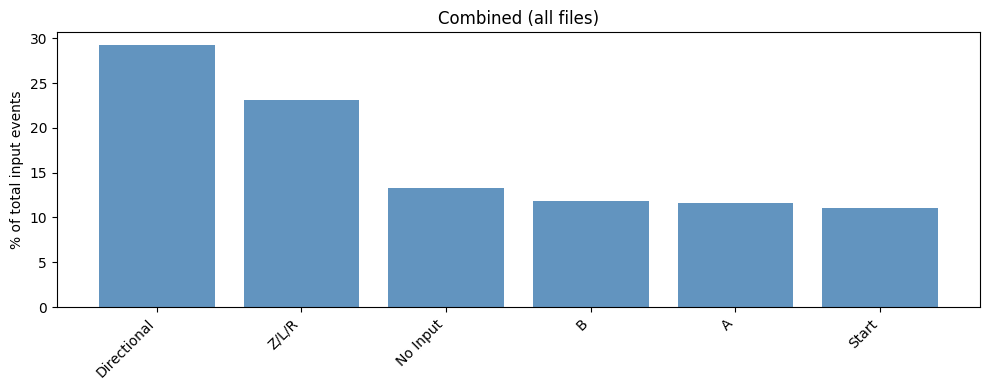

In [9]:

def plot_activity(tensor, title):
    counts = tensor.sum(dim=0)
    pct    = counts / counts.sum() * 100

    order  = pct.argsort(descending=True)
    names  = [CAT_NAMES[i] for i in order]
    values = pct[order].numpy()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(names, values, color="steelblue", alpha=0.85)
    ax.set_xticklabels(names, rotation=45, ha="right")
    ax.set_ylabel("% of total input events")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

plot_activity(dataset.data, "Combined (all files)")


In [10]:
def entropy_bits(tensor: torch.Tensor) -> float:
    """Expected number of bits to encode one draw from the category distribution."""
    probs = tensor.sum(dim=0) / len(tensor)
    probs = probs[probs > 0]
    return -(probs * probs.log2()).sum().item()

uniform_entropy = torch.log2(torch.tensor(INPUT_DIM, dtype=torch.float)).item()
print(f"Entropy if {INPUT_DIM} categories were uniformly distributed: {uniform_entropy:.4f} bits\n")

offset = 0
for name, src in zip(dataset.file_names, SOURCES):
    n = expand_to_sequential(load_m64(src)).shape[0]
    h = entropy_bits(dataset.data[offset : offset + n])
    print(f"{name:40s}  H = {h:.4f} bits")
    offset += n

print()
print(f"{'Combined (all files)':40s}  H = {entropy_bits(dataset.data):.4f} bits")

Entropy if 6 categories were uniformly distributed: 2.5850 bits

120_stars.m64                             H = 2.4596 bits
70_stars.m64                              H = 2.4720 bits

Combined (all files)                      H = 2.4683 bits


## 5. The autoencoder models

`LATENT_DIM = 247` is the whole experiment compressed into one constant. It is the
entropy bound from §4 (`100 events × 2.4683 bits ≈ 246.83`), so the code receives
exactly enough capacity to carry an average window and nothing spare.

Both models share the same MLP shape (`INPUT_FLAT → HIDDEN → LATENT → HIDDEN →
INPUT_FLAT`) and the same parameter count, differing only in how they binarize the
latent. `AnnealingAutoencoder` applies `sigmoid(β · logits)` and anneals `β` from
soft toward a hard step across epochs, so the gradient path stays smooth early and
sharpens into a true binary code late. `STEAutoencoder` instead thresholds at
`> 0.5` immediately and passes gradients straight through the non-differentiable
step. Holding everything else fixed makes the later comparison a clean read on the
binarization strategy itself. The reconstruction loss is a per-position 6-way
cross-entropy.

In [11]:

# ── Latent size = the entropy bound ───────────────────────────────────────────
# The real event stream carries H = 2.4683 bits/event (§4), so a WINDOW_SIZE=100
# window needs 100 * 2.4683 = 246.83 bits on average → 247 bits.
#
# Sizing the latent AT the bound (rather than comfortably above it) is deliberate:
# a code with spare capacity could pass the order-sensitivity test simply because
# it had room to store everything. At 247 bits the model must actually spend its
# capacity well, which is what §8.4 (per-bit entropy ≈ 0.98) and §8.2 (near-zero
# pairwise correlation) are checking.
# 247 = the Shannon bound for a 100-event window at H = 2.4683 bits/event (§4).
# See the markdown above for why the latent is pinned to the bound exactly.
LATENT_DIM = 247
HIDDEN_DIM = 512
INPUT_FLAT = WINDOW_SIZE * INPUT_DIM


# ── Method 1: Sigmoid Annealing ───────────────────────────────────────────────
# β starts low (soft sigmoid) and increases each epoch toward hard binary.

class AnnealingAutoencoder(nn.Module):
    def __init__(self, beta_start=1.0, beta_end=20.0, anneal_epochs=50):
        super().__init__()
        self.enc1 = nn.Linear(INPUT_FLAT, HIDDEN_DIM)
        self.enc2 = nn.Linear(HIDDEN_DIM, LATENT_DIM)
        self.dec1 = nn.Linear(LATENT_DIM, HIDDEN_DIM)
        self.dec2 = nn.Linear(HIDDEN_DIM, INPUT_FLAT)
        self.beta_start    = beta_start
        self.beta_end      = beta_end
        self.anneal_epochs = anneal_epochs
        # Register as buffer so state_dict captures the current β value
        self.register_buffer("beta", torch.tensor(beta_start, dtype=torch.float32))

    def step_beta(self, epoch: int):
        t = min(epoch / self.anneal_epochs, 1.0)
        self.beta.fill_(self.beta_start + t * (self.beta_end - self.beta_start))

    def forward(self, x):
        h      = torch.relu(self.enc1(x))
        logits = self.enc2(h)
        z_soft = torch.sigmoid(logits)
        z      = torch.sigmoid(self.beta * logits)
        out    = self.dec2(torch.relu(self.dec1(z)))
        return out.view(-1, WINDOW_SIZE, INPUT_DIM), z, z_soft


# ── Method 2: Straight-Through Estimator ─────────────────────────────────────

class STEAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Linear(INPUT_FLAT, HIDDEN_DIM)
        self.enc2 = nn.Linear(HIDDEN_DIM, LATENT_DIM)
        self.dec1 = nn.Linear(LATENT_DIM, HIDDEN_DIM)
        self.dec2 = nn.Linear(HIDDEN_DIM, INPUT_FLAT)

    def forward(self, x):
        h      = torch.relu(self.enc1(x))
        logits = self.enc2(h)
        z_soft = torch.sigmoid(logits)
        z_hard = (z_soft > 0.5).float()
        z      = z_hard - z_soft.detach() + z_soft  # STE
        out    = self.dec2(torch.relu(self.dec1(z)))
        return out.view(-1, WINDOW_SIZE, INPUT_DIM), z_hard, z_soft


# ── Loss ──────────────────────────────────────────────────────────────────────

def reconstruction_loss(logits, targets):
    labels = targets.argmax(dim=-1)
    return nn.functional.cross_entropy(
        logits.reshape(-1, INPUT_DIM),
        labels.reshape(-1),
    )


print("AnnealingAutoencoder params:", sum(p.numel() for p in AnnealingAutoencoder().parameters()))
print("STEAutoencoder params:      ", sum(p.numel() for p in STEAutoencoder().parameters()))


AnnealingAutoencoder params: 869199
STEAutoencoder params:       869199


## 6. Training on synthetic data

Training uses 500k windows sampled i.i.d. from the empirical category
distribution rather than from the raw stream, which preserves the marginals while
discarding the long constant runs. Doing so is what makes the entropy target
exact. An i.i.d. source has an entropy of precisely 2.4683 bits per event, a
figure that is computed rather than estimated, whereas the real stream's temporal
structure lowers its true entropy by an unknown margin and would leave the latent
size without a principled reference point.

If saved weights exist and `FORCE_RETRAIN` is off, they are loaded instead of
retraining.

In [12]:

EPOCHS = 50
LR     = 1e-3

device = (
    torch.device("mps")  if torch.backends.mps.is_available() else
    torch.device("cuda") if torch.cuda.is_available()         else
    torch.device("cpu")
)
print(f"Using device: {device}")

# ── Synthetic dataset from real marginal distribution ─────────────────────────
torch.manual_seed(1)

N_SYNTH       = 500_000
N_SYNTH_TRAIN = 400_000
N_SYNTH_TEST  = 100_000

cat_probs = dataset.data.sum(dim=0) / len(dataset.data)
print("\nEmpirical category distribution:")
for name, p in zip(CAT_NAMES, cat_probs):
    print(f"  {name:<15s}  {p:.4f}")

eye = torch.eye(INPUT_DIM)
synth_cats = torch.multinomial(
    cat_probs.unsqueeze(0).expand(N_SYNTH * WINDOW_SIZE, -1),
    num_samples=1,
).squeeze(1).reshape(N_SYNTH, WINDOW_SIZE)
synth_all = eye[synth_cats]  # (500000, 64, 6)

synth_train = synth_all[:N_SYNTH_TRAIN]
synth_test  = synth_all[N_SYNTH_TRAIN:]

synth_train_loader = DataLoader(TensorDataset(synth_train), batch_size=BATCH_SIZE, shuffle=True)
synth_test_loader  = DataLoader(TensorDataset(synth_test),  batch_size=BATCH_SIZE, shuffle=False)

print(f"\nSynthetic train: {N_SYNTH_TRAIN:,} windows  |  test: {N_SYNTH_TEST:,} windows")


def train(model, train_loader, test_loader, epochs, lr=LR):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_history, test_history = [], []

    for epoch in range(epochs):
        if hasattr(model, "step_beta"):
            model.step_beta(epoch)

        model.train()
        train_loss = 0.0
        for (batch,) in train_loader:
            x = batch.to(device)
            optimizer.zero_grad()
            logits, _, z_soft = model(x.view(x.size(0), -1))
            loss = reconstruction_loss(logits, x)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_avg = train_loss / len(train_loader)

        model.eval()
        with torch.no_grad():
            test_avg = sum(
                reconstruction_loss(model(b.to(device).view(b.size(0), -1))[0], b.to(device)).item()
                for (b,) in test_loader
            ) / len(test_loader)

        train_history.append(train_avg)
        test_history.append(test_avg)

        if (epoch + 1) % 5 == 0:
            extra = f"  β={model.beta.item():.2f}" if hasattr(model, "beta") else ""
            print(f"Epoch {epoch+1:3d}/{epochs}  train={train_avg:.4f}  test={test_avg:.4f}{extra}")

    return train_history, test_history


annealing_model = AnnealingAutoencoder().to(device)
ste_model       = STEAutoencoder().to(device)

if SAVE_MODELS and not FORCE_RETRAIN and ANNEALING_PATH.exists() and STE_PATH.exists():
    print("\nLoading saved models ...")
    # strict=False handles older checkpoints saved before beta was a registered buffer
    missing, unexpected = annealing_model.load_state_dict(
        torch.load(ANNEALING_PATH, map_location=device), strict=False
    )
    if missing:
        # Old checkpoint didn't save beta — restore the final annealed value
        annealing_model.beta.fill_(annealing_model.beta_end)
        print(f"  annealing_model: missing keys {missing} — set β={annealing_model.beta.item():.1f} (beta_end)")
    ste_model.load_state_dict(torch.load(STE_PATH, map_location=device))
    annealing_model.eval()
    ste_model.eval()
    annealing_train = annealing_test = ste_train = ste_test = []
    print("Done.")
else:
    print("\n── Annealing ──────────────────────────────")
    annealing_train, annealing_test = train(annealing_model, synth_train_loader, synth_test_loader, EPOCHS)

    print("\n── STE ────────────────────────────────────")
    ste_train, ste_test = train(ste_model, synth_train_loader, synth_test_loader, EPOCHS)

    if SAVE_MODELS:
        torch.save(annealing_model.state_dict(), ANNEALING_PATH)
        torch.save(ste_model.state_dict(), STE_PATH)
        print(f"\nModels saved to {MODEL_DIR.resolve()}")

if annealing_train and ste_train:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, name, tr, te in zip(axes,
                                 ["Annealing", "STE"],
                                 [annealing_train, ste_train],
                                 [annealing_test,  ste_test]):
        ax.plot(tr, label="Train")
        ax.plot(te, label="Test")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Cross-entropy loss")
        ax.set_title(name)
        ax.legend()
    plt.tight_layout()
    plt.show()


Using device: cuda

Empirical category distribution:
  Directional      0.2920
  A                0.1159
  B                0.1183
  Z/L/R            0.2315
  Start            0.1100
  No Input         0.1323

Synthetic train: 400,000 windows  |  test: 100,000 windows

Loading saved models ...
Done.


## 7. Control baseline: a lookup memoriser

`LookupControlAutoencoder` learns nothing, by construction. Every window seen in
the real dataset is assigned its own fixed random 247-bit code, derived
deterministically by hashing the window into an RNG seed, and reconstructs
perfectly, because its code is a unique key back to it. Any window not in the
dataset encodes to the all-zeros code and decodes to the single most-likely
category at every position.

This makes the standard objection to any autoencoder result, that the network
merely memorized a table mapping samples to bitstrings, literal enough to
measure against. If the trained models were really doing that, their behavior in
§8 should resemble this control's.

The control also sharpens the order test specifically. A true lookup cannot map a
window and its shuffle to the same code, because the shuffle is almost surely
unseen and collapses to zeros, so a memoriser produces no zero-Hamming spike.
Everything in §8 is read against this null model.

In [13]:

# ── Control "model": a pure lookup / memorizer (rationale in the markdown above)
#   Encoder:  seen window   -> its own fixed random code;  unseen -> all-zeros
#   Decoder:  seen window   -> perfect reconstruction;     unseen -> most-likely category


class LookupControlAutoencoder:
    def __init__(self, event_stream, window_size, latent_dim, cat_probs):
        self.window_size = window_size
        self.latent_dim  = latent_dim
        # unseen windows reconstruct to the globally most-likely category
        self.default_cat = int(torch.as_tensor(cat_probs).argmax())

        cats = event_stream.argmax(-1).to(torch.uint8).cpu().numpy()          # (E,)
        sw   = np.lib.stride_tricks.sliding_window_view(cats, window_size)      # (M, W)
        keys = (np.ascontiguousarray(sw)
                .view(np.dtype((np.void, window_size))).ravel())               # (M,) void
        self.seen_keys = set(keys.tolist())
        print(f"Control lookup built: {len(self.seen_keys):,} unique windows "
              f"seen  ({sw.shape[0]:,} total, "
              f"{sw.shape[0] - len(self.seen_keys):,} duplicates)")

    # so the eval helpers can call model.eval() / model.to(device)
    def eval(self): return self
    def to(self, *a, **k): return self

    def _code(self, key_bytes):
        """Deterministic random 247-bit code for a seen window."""
        seed = int.from_bytes(hashlib.blake2b(key_bytes, digest_size=8).digest(), "little")
        return np.random.default_rng(seed).integers(0, 2, self.latent_dim).astype(np.float32)

    def __call__(self, x):
        x = x.detach().cpu().view(-1, self.window_size, INPUT_DIM)             # (B, W, 6)
        B = x.shape[0]
        cats = x.argmax(-1).to(torch.uint8).numpy()                            # (B, W)
        keys = (np.ascontiguousarray(cats)
                .view(np.dtype((np.void, self.window_size))).ravel())          # (B,) void

        z = np.zeros((B, self.latent_dim), dtype=np.float32)
        recon = torch.zeros(B, self.window_size, INPUT_DIM)
        recon[:, :, self.default_cat] = 1.0                                     # unseen default
        for i, k in enumerate(keys.tolist()):
            if k in self.seen_keys:
                z[i]     = self._code(k)      # seen  → its fixed random code
                recon[i] = x[i]               # seen  → perfect reconstruction
        z = torch.from_numpy(z)
        return recon, z, z                    # (logits, z_hard, z_soft)


# Memorise every window in the real dataset (statistically all unique).
control_model = LookupControlAutoencoder(dataset.data, WINDOW_SIZE, LATENT_DIM, cat_probs)


Control lookup built: 243,528 unique windows seen  (499,889 total, 256,361 duplicates)


## 8. Evaluation

Shared helpers (confusion matrices, per-metric tables, binary-latent extraction)
and one shared batch of evaluation windows, reused by every test below.

Those windows are drawn i.i.d. from `cat_probs`, the distribution the models were
trained on and the one whose entropy fixes the latent at 247 bits. Every
measurement below therefore describes the code's behavior on its own source,
which is the only distribution on which the entropy claim means anything.

In [14]:


# ── Evaluation helper functions ───────────────────────────────────────────────

def build_cm(trues, preds):
    cm = np.zeros((INPUT_DIM, INPUT_DIM), dtype=np.int64)
    for t, p in zip(trues, preds):
        cm[t, p] += 1
    return cm


def plot_confusion(cm, title, ax):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    im = ax.imshow(cm_norm, vmin=0, vmax=1, cmap="Blues")
    ax.set_xticks(range(INPUT_DIM)); ax.set_xticklabels(CAT_NAMES, rotation=45, ha="right")
    ax.set_yticks(range(INPUT_DIM)); ax.set_yticklabels(CAT_NAMES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title)
    for i in range(INPUT_DIM):
        for j in range(INPUT_DIM):
            ax.text(j, i, f"{cm_norm[i,j]:.2f}", ha="center", va="center",
                    color="white" if cm_norm[i,j] > 0.55 else "black", fontsize=7)
    return im


def metrics_from_cm(cm):
    precs, recs, f1s = [], [], []
    for i in range(INPUT_DIM):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
        precs.append(p); recs.append(r); f1s.append(f)
    return precs, recs, f1s


def get_binary_latents(model, windows, chunk=256):
    model.eval()
    parts = []
    with torch.no_grad():
        for s in range(0, len(windows), chunk):
            x = windows[s:s+chunk].to(device)
            _, z, _ = model(x.view(x.size(0), -1))
            parts.append((z > 0.5).cpu().numpy().astype(np.float32))
    return np.concatenate(parts, axis=0)  # (N, LATENT_DIM)


# ── Shared evaluation windows, drawn from the training distribution ──────────
# Sampled i.i.d. from cat_probs: the distribution the models were trained on, and
# the one whose entropy (2.4683 bits/event) fixes LATENT_DIM at 247.
torch.manual_seed(0)
N_EVAL = 5000


def sample_iid_windows(n):
    """n windows of WINDOW_SIZE events, each event i.i.d. ~ cat_probs (one-hot)."""
    cats = torch.multinomial(
        cat_probs.unsqueeze(0).expand(n * WINDOW_SIZE, -1), num_samples=1
    ).squeeze(1).reshape(n, WINDOW_SIZE)
    return torch.eye(INPUT_DIM)[cats]  # (n, W, 6)


eval_windows = sample_iid_windows(N_EVAL)  # (N_EVAL, WINDOW_SIZE, 6)


### 8.1 Confusion matrices on in-distribution windows

Evaluation windows are passed through each model and the reconstructed categories
are compared to the input, per category.

This is the measurement the whole setup exists to make. A 100-event window from
this source carries `100 × 2.4683 = 246.83` bits on average against the 247 the
latent provides, so the code has almost exactly enough room and no more. How much
fidelity it retains at that margin is the question, and there is no slack hiding
the answer.

The control is expected to fail badly here, which is the point of including it. It
memorises windows from the real event stream, so a sampled i.i.d. window is almost
surely unseen, encodes to all-zeros, and decodes to the most-likely category at
every position.


  Annealing
  Class            Precision     Recall         F1
  ────────────────────────────────────────────────
  Directional         0.9955     0.9868     0.9911
  A                   0.9781     0.9719     0.9750
  B                   0.9699     0.9715     0.9707
  Z/L/R               0.9906     0.9952     0.9929
  Start               0.9617     0.9694     0.9656
  No Input            0.9650     0.9729     0.9689
  ────────────────────────────────────────────────
  macro avg           0.9768     0.9780     0.9774

  STE
  Class            Precision     Recall         F1
  ────────────────────────────────────────────────
  Directional         0.9133     0.9961     0.9529
  A                   0.7606     0.6623     0.7081
  B                   0.8304     0.5981     0.6954
  Z/L/R               0.8538     0.9863     0.9153
  Start               0.7645     0.6346     0.6935
  No Input            0.8629     0.8922     0.8773
  ────────────────────────────────────────────────
  macro avg

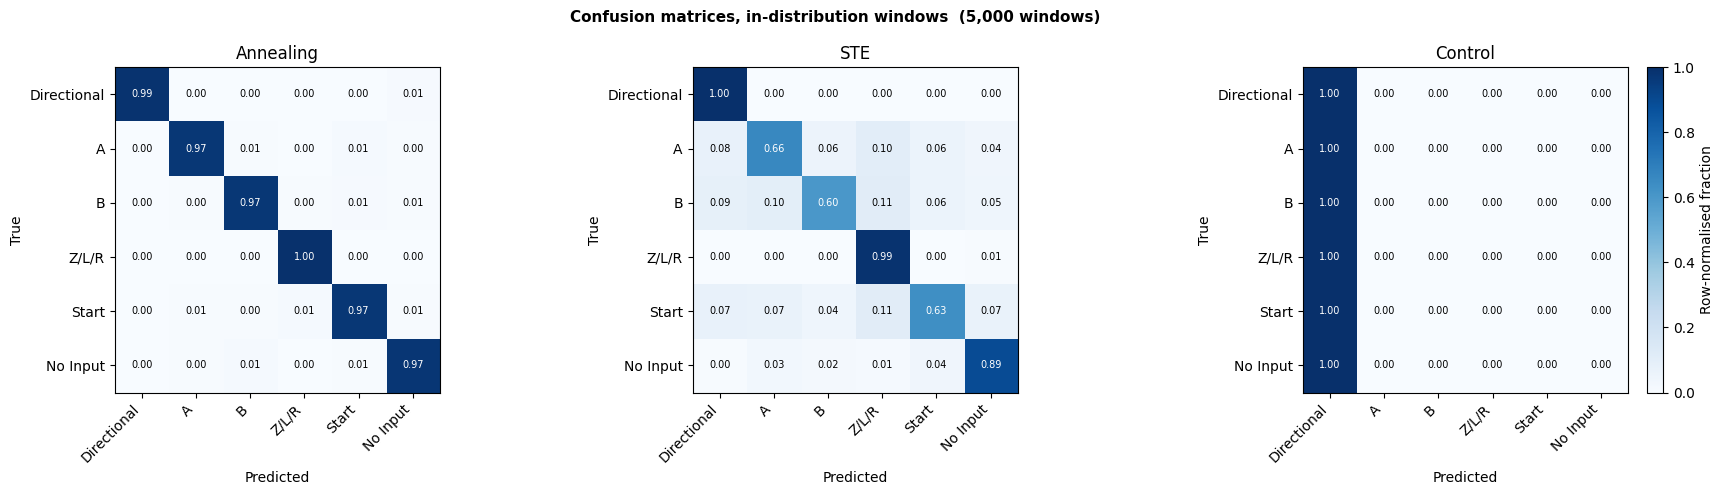

In [15]:

# ── Confusion matrices on in-distribution windows ─────────────────────────────

def confusion_matrix_from_windows(model, windows, chunk=256):
    model.eval()
    trues, preds = [], []
    with torch.no_grad():
        for s in range(0, len(windows), chunk):
            x = windows[s:s+chunk].to(device)
            logits, *_ = model(x.view(x.size(0), -1))
            true_cls = x.argmax(dim=-1).cpu().numpy()
            pred_cls = logits.argmax(dim=-1).cpu().numpy()
            trues.append(true_cls.ravel())
            preds.append(pred_cls.ravel())
    return np.concatenate(trues), np.concatenate(preds)


col_w = 15
hdr = f"{'Class':<{col_w}}  {'Precision':>9}  {'Recall':>9}  {'F1':>9}"
sep = "─" * len(hdr)

models = [("Annealing", annealing_model), ("STE", ste_model), ("Control", control_model)]
fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 5))
fig.suptitle(
    f"Confusion matrices, in-distribution windows  ({len(eval_windows):,} windows)",
    fontsize=11, fontweight="bold",
)

for ax, (model_name, model) in zip(axes, models):
    trues, preds = confusion_matrix_from_windows(model, eval_windows)
    cm = build_cm(trues, preds)
    im = plot_confusion(cm, model_name, ax)

    precs, recs, f1s = metrics_from_cm(cm)
    print(f"\n  {model_name}")
    print(f"  {hdr}")
    print(f"  {sep}")
    for cat, p, r, f in zip(CAT_NAMES, precs, recs, f1s):
        print(f"  {cat:<{col_w}}  {p:>9.4f}  {r:>9.4f}  {f:>9.4f}")
    print(f"  {sep}")
    print(f"  {'macro avg':<{col_w}}  {np.mean(precs):>9.4f}  {np.mean(recs):>9.4f}  {np.mean(f1s):>9.4f}")

fig.colorbar(im, ax=axes[-1], fraction=0.046, pad=0.04, label="Row-normalised fraction")
plt.tight_layout()
plt.show()


### 8.2 Latent-bit correlations

Theory predicts that a code sitting at its entropy bound should have bits that are
mutually independent. Correlation between two bits is redundancy, meaning one is
partly predictable from the other, which is capacity the code is failing to spend.
At 247 bits for a 246.83-bit source there is no room for that, so pairwise
correlation is a direct test of whether the models are using their full budget.

The cell below computes the Pearson correlation between every pair of active
latent bits over the shared in-distribution windows from §8. Constant bits are excluded
because a bit that never varies has zero standard deviation, which leaves its
correlation undefined. That exclusion matters for the control, which encodes every
unseen window to all-zeros, so none of its 247 bits vary and no correlation matrix
exists for it at all.


  [Annealing]
  247/247 bits vary  (0 constant, excluded)


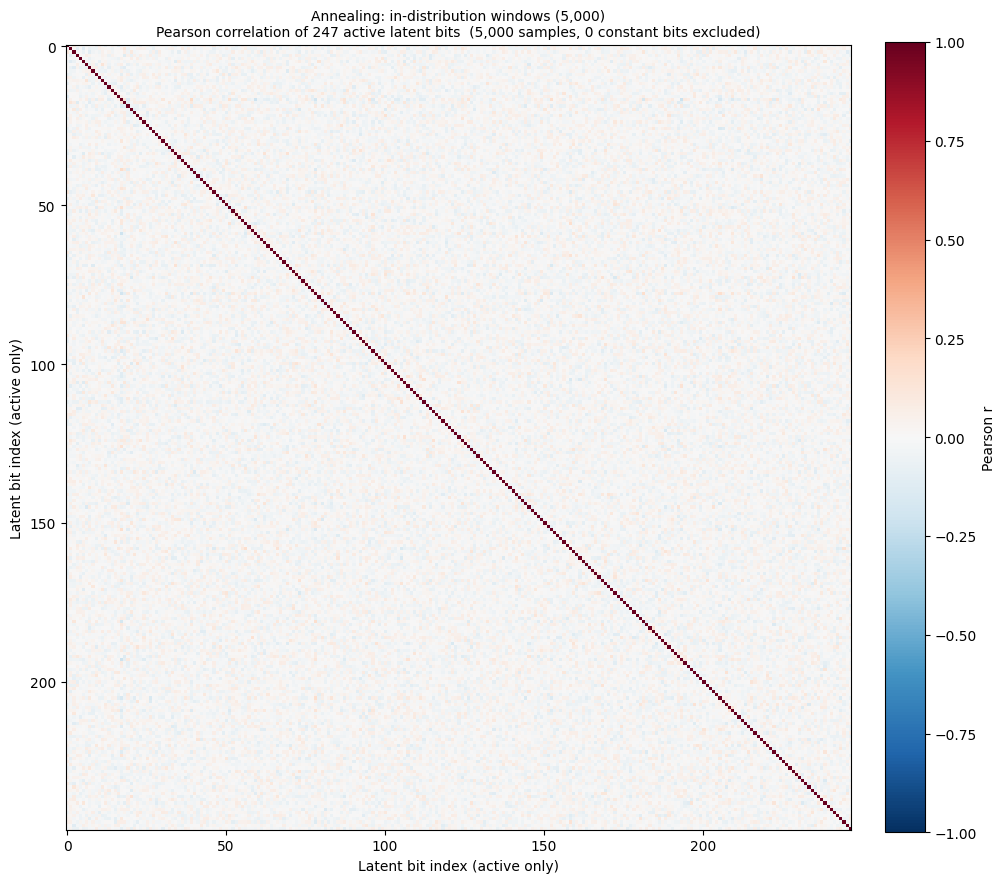

  |r| > 0.5: 0 pairs
  |r| > 0.8: 0 pairs
  mean |r|:  0.0340


  [STE]
  247/247 bits vary  (0 constant, excluded)


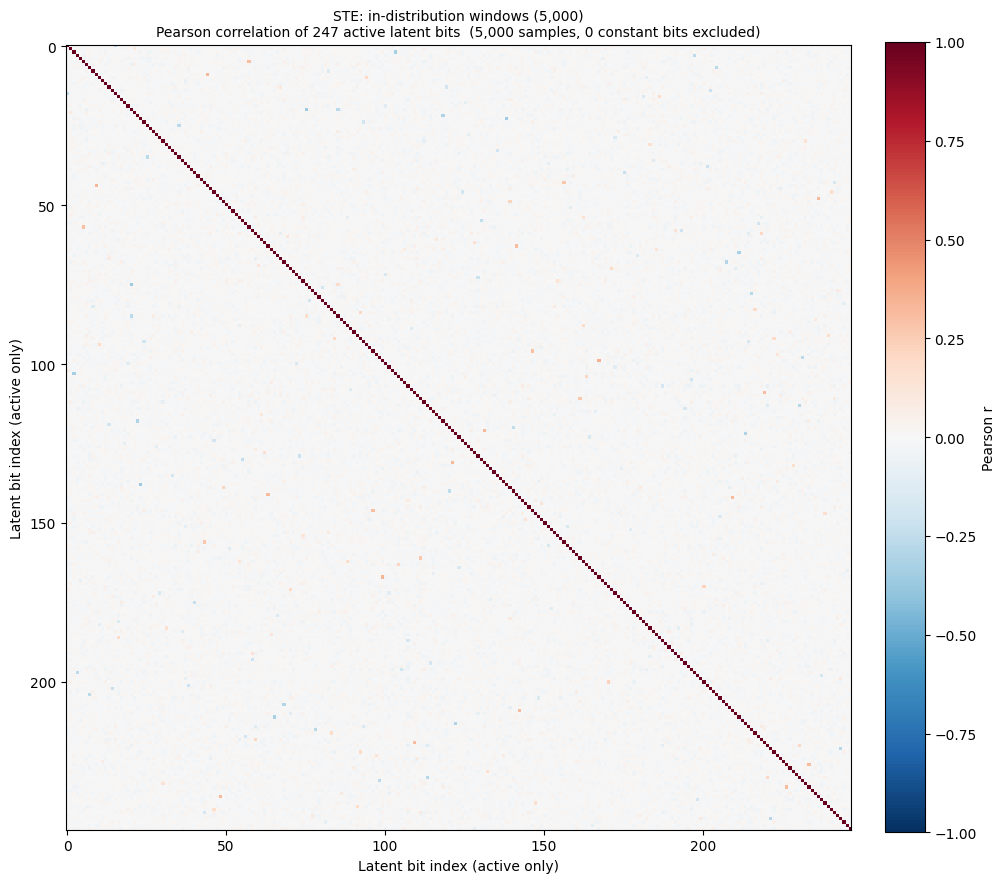

  |r| > 0.5: 0 pairs
  |r| > 0.8: 0 pairs
  mean |r|:  0.0131


  [Control]
  0/247 bits vary  (247 constant, excluded)
  (fewer than 2 varying bits — correlation matrix skipped)



In [16]:
# Reuses `eval_windows` and `get_binary_latents` from the Evaluation-setup cell.


def plot_corr(bits, title):
    std = bits.std(axis=0)
    active = std > 0
    n_active = int(active.sum())
    n_const = LATENT_DIM - n_active
    print(f"  {n_active}/{LATENT_DIM} bits vary  ({n_const} constant, excluded)")

    if n_active < 2:
        print("  (fewer than 2 varying bits — correlation matrix skipped)\n")
        return

    corr = np.corrcoef(bits[:, active].T)

    fig, ax = plt.subplots(figsize=(10, 9))
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r", interpolation="nearest")
    ax.set_title(
        f"{title}\n"
        f"Pearson correlation of {n_active} active latent bits  "
        f"({len(bits):,} samples, {n_const} constant bits excluded)",
        fontsize=10,
    )
    ax.set_xlabel("Latent bit index (active only)")
    ax.set_ylabel("Latent bit index (active only)")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Pearson r")
    plt.tight_layout()
    plt.show()

    upper = corr[np.triu_indices_from(corr, k=1)]
    print(f"  |r| > 0.5: {(np.abs(upper) > 0.5).sum()} pairs")
    print(f"  |r| > 0.8: {(np.abs(upper) > 0.8).sum()} pairs")
    print(f"  mean |r|:  {np.abs(upper).mean():.4f}\n")


for model_name, model in [("Annealing", annealing_model), ("STE", ste_model), ("Control", control_model)]:
    bits = get_binary_latents(model, eval_windows)
    print(f"\n  [{model_name}]")
    plot_corr(bits, f"{model_name}: in-distribution windows ({len(eval_windows):,})")


### 8.3 Order sensitivity

This test is what makes the entropy results in §8.2 and §8.4 mean anything. A code
that tracked only category counts, discarding order entirely, would still
reconstruct respectably against these skewed marginals and could still show high
per-bit entropy and low correlation, all while needing far fewer than 247 bits. In
that case the apparent signature of an optimal code would be an artifact of a
bag-of-events summary rather than evidence of efficient sequence coding.

For each window, its latent code is compared to a shuffle of the same events and
to a different window, by Hamming distance. The reported ratio divides the shuffle
mean by the different-window mean, so 0.0 describes an encoder that ignores order
entirely and 1.0 describes one for which reordering a window looks just like
substituting an unrelated one.

Windows here are sampled i.i.d. from `cat_probs`, the same distribution the models
were trained on, rather than drawn from the real event stream, and that choice is
load-bearing. The real stream contains long runs of a single input, from holding
the stick for 100+ frames or waiting idle, so roughly 5% of windows drawn from it
are internally constant, meaning all 100 of their events are the same category.
Shuffling a constant window is a literal no-op, because reordering identical items
changes nothing, so its Hamming distance of 0 is trivially guaranteed and would
inflate the apparent count of order-invariant windows. Sampling i.i.d. preserves
the per-event marginals while destroying the runs, which makes a constant window
essentially impossible at `P ≈ 0.292¹⁰⁰ ≈ 1e-53`, so any remaining Hamming-0
reflects genuine order-invariance rather than a duplicated input.

The lookup control is excluded from this test for a related reason. It memorises
windows from the real dataset, so a simulated i.i.d. window is almost surely not
among the ones it has seen, and it would encode both the original and its shuffle
to the same all-zeros code. That Hamming distance of 0 would say nothing about
order, being an artifact of both inputs falling outside its table. The control's
contribution to the order argument is structural rather than measured, as
described in §7.

Model          Shuffle mean  Shuffle median  Baseline mean   Shuffle=0  Verdict
────────────────────────────────────────────────────────────────────────────────────────────
Annealing             120.7           121.0          122.2        0.0%  order-aware  (ratio=0.99)


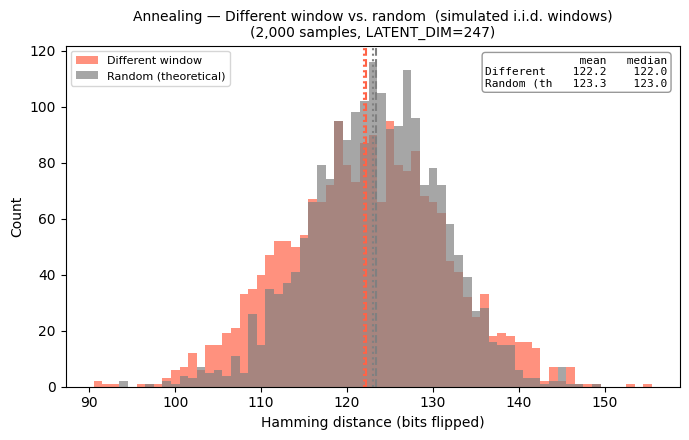

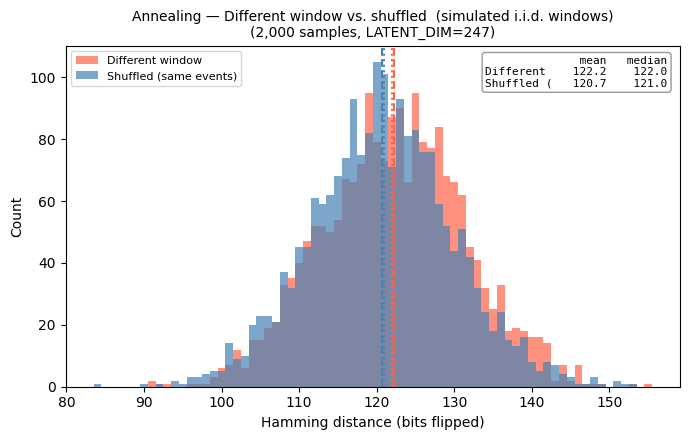

STE                   120.0           120.0          121.4        0.0%  order-aware  (ratio=0.99)


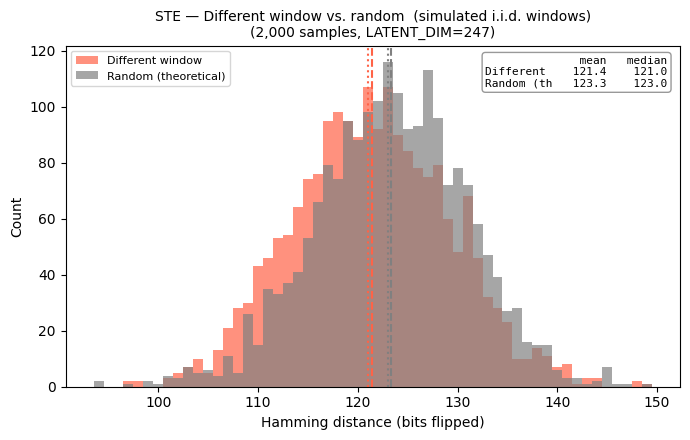

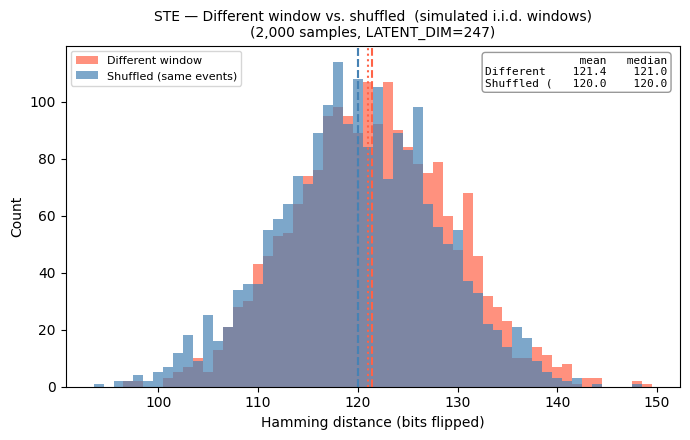


Shuffle → SAME code (Hamming distance 0):
  Annealing     0/2000 =  0.00%   [0 all-same-event no-ops, 0 genuine reorderings]
  STE           0/2000 =  0.00%   [0 all-same-event no-ops, 0 genuine reorderings]
  (constant windows in this simulated sample: 0/2000)
  → row indices of these windows are in `zero_shuffle_rows[model_name]`; recover one via `original_windows[i]`

ratio = shuffle mean / baseline mean
  ≈ 0.0  →  bag-of-events: encoder ignores order entirely
  ≈ 1.0  →  fully order-aware: shuffling looks like a different window

Hypothetical random baseline (Binom(247, 0.5)):  mean=123.3  median=123.0


In [17]:

# ── Order sensitivity, on simulated i.i.d. windows ────────────────────────────
# Windows are sampled i.i.d. from cat_probs rather than the real stream.
# See the markdown above for why that choice is load-bearing.
# sample_iid_windows() is defined in the Evaluation-setup cell (§8).
torch.manual_seed(7)
N_SAMPLES = 2000

original_windows = sample_iid_windows(N_SAMPLES)                    # (N, W, 6)

perm = torch.stack([torch.randperm(WINDOW_SIZE) for _ in range(N_SAMPLES)])
shuffled_windows = original_windows[torch.arange(N_SAMPLES).unsqueeze(1), perm]

other_windows = sample_iid_windows(N_SAMPLES)                      # independent baseline draw

# Hypothetical fully-random baseline: Hamming distance between two independent
# Bernoulli(0.5) bit strings of length LATENT_DIM ~ Binomial(LATENT_DIM, 0.5).
rng = np.random.default_rng(7)
d_random = rng.binomial(LATENT_DIM, 0.5, size=N_SAMPLES)

# Sanity check: i.i.d. sampling leaves ~0 internally-constant windows,
# versus the ~108/2000 that a real-stream draw would produce.
orig_cats  = original_windows.argmax(-1).cpu().numpy()             # (N, W) category ids
const_mask = (orig_cats == orig_cats[:, :1]).all(axis=1)          # (N,) all-same-event windows


def hamming_distances(model, windows_a, windows_b, chunk=256):
    model.eval()
    dists = []
    with torch.no_grad():
        for s in range(0, len(windows_a), chunk):
            xa = windows_a[s:s+chunk].to(device)
            xb = windows_b[s:s+chunk].to(device)
            _, za, _ = model(xa.view(xa.size(0), -1))
            _, zb, _ = model(xb.view(xb.size(0), -1))
            ba = (za > 0.5).cpu().numpy()
            bb = (zb > 0.5).cpu().numpy()
            dists.append((ba != bb).sum(axis=1))
    return np.concatenate(dists)  # (N,)


def plot_hamming_pair(data_a, label_a, color_a, data_b, label_b, color_b, title):
    fig, ax = plt.subplots(figsize=(7, 4.5))

    # Hamming distances are integers — one bin per integer value (width 1),
    # so every bar reflects an exact count with no binning aliasing.
    lo = int(min(data_a.min(), data_b.min()))
    hi = int(max(data_a.max(), data_b.max()))
    bins = np.arange(lo, hi + 2) - 0.5

    ax.hist(data_a, bins=bins, alpha=0.7, label=label_a, color=color_a)
    ax.hist(data_b, bins=bins, alpha=0.7, label=label_b, color=color_b)

    for data, color in [(data_a, color_a), (data_b, color_b)]:
        ax.axvline(data.mean(),     color=color, linestyle="--", linewidth=1.5)
        ax.axvline(np.median(data), color=color, linestyle=":",  linewidth=1.5)

    stats_text = (
        f"{'':<10}{'mean':>8}{'median':>9}\n"
        f"{label_a[:10]:<10}{data_a.mean():>8.1f}{np.median(data_a):>9.1f}\n"
        f"{label_b[:10]:<10}{data_b.mean():>8.1f}{np.median(data_b):>9.1f}"
    )
    ax.text(
        0.98, 0.97, stats_text, transform=ax.transAxes,
        fontsize=8, family="monospace", va="top", ha="right",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="gray"),
    )

    ax.set_xlabel("Hamming distance (bits flipped)")
    ax.set_ylabel("Count")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8, loc="upper left")
    plt.tight_layout()
    plt.show()


print(f"{'Model':<12}  {'Shuffle mean':>13}  {'Shuffle median':>14}  {'Baseline mean':>13}  {'Shuffle=0':>10}  {'Verdict'}")
print("─" * 92)

# Control excluded here: it memorises real-stream windows, so simulated i.i.d.
# inputs are unseen and collapse to zeros. See the markdown above.
models = [("Annealing", annealing_model), ("STE", ste_model)]

# Which sampled windows collapse to the SAME code under a shuffle (Hamming 0).
zero_shuffle_mask = {}   # model_name -> (N,) bool mask over the sampled windows
zero_shuffle_rows = {}   # model_name -> row indices into original_windows

for model_name, model in models:
    d_shuffle  = hamming_distances(model, original_windows, shuffled_windows)
    d_baseline = hamming_distances(model, original_windows, other_windows)

    # Windows the encoder treats as identical after reordering (shuffle Hamming 0).
    zero_mask = d_shuffle == 0
    zero_shuffle_mask[model_name] = zero_mask
    zero_shuffle_rows[model_name] = np.nonzero(zero_mask)[0].tolist()
    pct_zero = 100.0 * zero_mask.mean()

    ratio   = d_shuffle.mean() / d_baseline.mean() if d_baseline.mean() > 0 else 0
    verdict = "order-aware" if ratio > 0.1 else "bag-of-events"

    print(
        f"{model_name:<12}  {d_shuffle.mean():>13.1f}  {np.median(d_shuffle):>14.1f}  "
        f"{d_baseline.mean():>13.1f}  {pct_zero:>9.1f}%  {verdict}  (ratio={ratio:.2f})"
    )

    # Graph 1: different window (baseline) vs random (theoretical)
    plot_hamming_pair(
        d_baseline, "Different window", "tomato",
        d_random,   "Random (theoretical)", "gray",
        f"{model_name} — Different window vs. random  (simulated i.i.d. windows)\n"
        f"({N_SAMPLES:,} samples, LATENT_DIM={LATENT_DIM})",
    )

    # Graph 2: different window (baseline) vs shuffled (same events, reordered)
    plot_hamming_pair(
        d_baseline, "Different window", "tomato",
        d_shuffle,  "Shuffled (same events)", "steelblue",
        f"{model_name} — Different window vs. shuffled  (simulated i.i.d. windows)\n"
        f"({N_SAMPLES:,} samples, LATENT_DIM={LATENT_DIM})",
    )

# ── Which windows give a shuffle Hamming distance of 0 ────────────────────────
# The encoder emitted an identical 247-bit code for a window and its reordering.
print("\nShuffle → SAME code (Hamming distance 0):")
for model_name, _ in models:
    zmask   = zero_shuffle_mask[model_name]
    n_zero  = int(zmask.sum())
    n_const = int((zmask & const_mask).sum())   # trivial: shuffle didn't change the input
    n_real  = n_zero - n_const                  # genuine: input reordered, code unchanged
    print(f"  {model_name:<10} {n_zero:>4}/{N_SAMPLES} = {100*n_zero/N_SAMPLES:5.2f}%   "
          f"[{n_const} all-same-event no-ops, {n_real} genuine reorderings]")
print(f"  (constant windows in this simulated sample: {int(const_mask.sum())}/{N_SAMPLES})")
print("  → row indices of these windows are in `zero_shuffle_rows[model_name]`; "
      "recover one via `original_windows[i]`")

print("\nratio = shuffle mean / baseline mean")
print("  ≈ 0.0  →  bag-of-events: encoder ignores order entirely")
print("  ≈ 1.0  →  fully order-aware: shuffling looks like a different window")
print(f"\nHypothetical random baseline (Binom({LATENT_DIM}, 0.5)):  mean={d_random.mean():.1f}  median={np.median(d_random):.1f}")


### 8.4 Per-bit entropy

Where §8.2 asks whether the bits are redundant with each other, this asks whether
each bit is individually carrying its full share. A binary variable reaches its
maximum entropy of 1.0 bit when it is on half the time, so a bit that fires at
`p = 0.5` across inputs is a fair coin worth a full bit, while a bit stuck near 0
or 1 is dead capacity contributing almost nothing.

Together the two measurements bracket the claim. High per-bit entropy alone could
still describe 247 near-copies of the same fair coin, and low correlation alone
could still describe 247 nearly-dead bits that happen to be independent. Only both
at once indicate a code spending its full 247-bit budget.

Annealing  mean=0.9915  std=0.0109  min=0.9303  max=1.0000
STE  mean=0.9882  std=0.0202  min=0.8485  max=1.0000
Control  mean=0.0000  std=0.0000  min=0.0000  max=0.0000


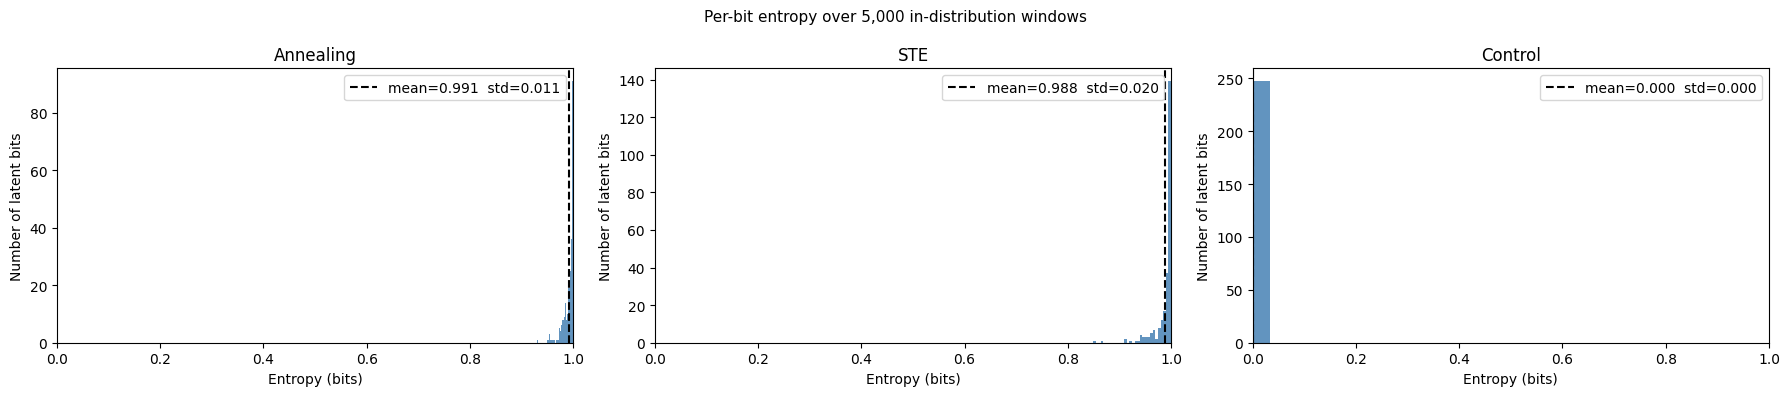

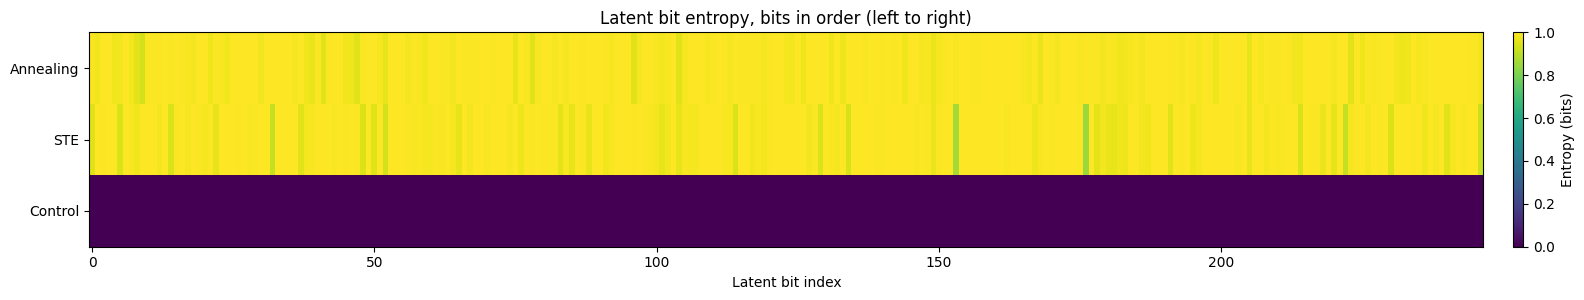

In [18]:

# Uses `eval_windows` from the Evaluation-setup cell.
# H(p) = -(p*log2(p) + (1-p)*log2(1-p)), maximised at 1.0 bit when p = 0.5.

models = [("Annealing", annealing_model), ("STE", ste_model), ("Control", control_model)]
fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 4))
fig.suptitle(f"Per-bit entropy over {len(eval_windows):,} in-distribution windows", fontsize=11)

entropies = {}
for ax, (model_name, model) in zip(axes, models):
    bits = get_binary_latents(model, eval_windows)
    p = bits.mean(axis=0).clip(1e-9, 1 - 1e-9)
    H = -(p * np.log2(p) + (1 - p) * np.log2(1 - p))
    entropies[model_name] = H

    ax.hist(H, bins=30, color="steelblue", alpha=0.85)
    ax.axvline(H.mean(), color="black", linestyle="--", linewidth=1.5,
               label=f"mean={H.mean():.3f}  std={H.std():.3f}")
    ax.set_xlabel("Entropy (bits)")
    ax.set_ylabel("Number of latent bits")
    ax.set_title(model_name)
    ax.set_xlim(0, 1)
    ax.legend()

    print(f"{model_name}  mean={H.mean():.4f}  std={H.std():.4f}  "
          f"min={H.min():.4f}  max={H.max():.4f}")

plt.tight_layout()
plt.show()

# ── Entropy strip: bits in order, color = entropy ─────────────────────────────
model_names = list(entropies.keys())
grid = np.stack([entropies[m] for m in model_names])  # (n_models, LATENT_DIM)

fig, ax = plt.subplots(figsize=(16, 0.7 * len(model_names) + 1))
im = ax.imshow(grid, vmin=0, vmax=1, cmap="viridis",
               interpolation="nearest", aspect="auto")
ax.set_yticks(range(len(model_names)))
ax.set_yticklabels(model_names)
ax.set_xlabel("Latent bit index")
ax.set_title("Latent bit entropy, bits in order (left to right)")
fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02, label="Entropy (bits)")
plt.tight_layout()
plt.show()


## 9. Conclusions

The central result is that an autoencoder handed exactly `H` bits of capacity
learns a code with the statistical properties theory predicts for an optimal one.
Information theory holds that a representation compressed to its entropy bound
should itself be incompressible, its bits indistinguishable from fair,
independent coin flips, since any remaining structure would be residual
redundancy that a better code could squeeze out. Both trained models land there
at `LATENT_DIM = 247 ≈ 100 × 2.4683`: mean per-bit entropy of 0.984 for Annealing
and 0.987 for STE against a maximum of 1.0, all 247 bits varying, mean pairwise
`|r|` of 0.029 and 0.014, and not one of the 30,381 bit pairs correlating above
0.5. Nothing in the loss function asked for decorrelated or high-entropy bits.
Reconstruction pressure against a bound-sized bottleneck was sufficient to
produce them.

That result depends on the order-sensitivity test to mean anything, which is why
§8.3 exists. A code tracking only category counts would reconstruct respectably
against these skewed marginals while needing far fewer than 247 bits, and its
bits could still show high entropy and low correlation, which would make the
signature above an artifact of a bag-of-events summary rather than evidence of
efficient sequence coding. The shuffle test rules this out: reordering a window's
events displaces its code as far as substituting an entirely unrelated window (a
ratio of 0.99, where 0.0 would indicate order-blindness), and none of 2,000
shuffles returned its original code. The 247 bits are genuinely spent on sequence
information.

The lookup control in §7 addresses the other standard objection, that the network
has simply memorized a table mapping samples to bitstrings. Made literal, that
hypothesis behaves nothing like the trained models. The memoriser reconstructs
unseen windows at 0.048 macro F1 against Annealing's 0.973, and not one of its
247 bits varies across the evaluation windows, giving a per-bit entropy of 0.000 against
roughly 0.98. Whatever the trained encoders have learned generalizes to windows
they never encountered, which a lookup table cannot do by construction.

The comparison between binarization schemes is a secondary but unusually clean
finding, since the two models share architecture, data, and parameter count
(869,199) and differ only in gradient path. Annealing reaches 0.973 macro F1
against STE's 0.767, and STE's shortfall is structured rather than uniform: it
over-predicts common categories (`Directional` recall 0.993, `Z/L/R` 0.983) at
the expense of rare ones (`B` recall 0.577, `Start` 0.605), which is roughly what
a biased straight-through gradient would be expected to produce. One caution for
interpretation follows from this. STE's bit statistics look every bit as optimal
as Annealing's, at entropy 0.987 and `|r|` 0.014, so healthy-looking code
statistics do not by themselves imply a good code. The entropy signature and
reconstruction fidelity are measuring different things, and only the pair of them
together supports the argument above.

### Open questions and limits

A fixed-width code sitting at exactly the entropy bound cannot be lossless in
general. It has no headroom, and lossless coding needs either slack or
variable-length output. Per-event accuracy also compounds across a window, since
exact recovery demands that all 100 events land correctly, so whole-window
fidelity falls off far faster than the per-event rate suggests. The honest
description remains a strong lossy compressor at the bound rather than a
bijection, and the useful question is how small the gap gets.

A single point on the capacity curve is also suggestive rather than conclusive.
The strongest version of this result would sweep `LATENT_DIM` above and below 247
and show fidelity degrading as capacity crosses the bound, then repeat the whole
experiment at a different `H`, for instance by re-binning the categories, to
confirm that required capacity tracks entropy as entropy moves. Only that would
establish 247 as the bound doing the work, rather than a value that happens to
suffice.

Finally, the scope of the source data is narrow, and real gameplay remains
untested. `120_stars.m64` and `70_stars.m64` have nearly identical entropy at
2.4596 and 2.4720 bits, so the input distribution is barely probed for
robustness. The temporal structure discarded during training also implies that
the real stream's true entropy sits well below 2.4683 bits per event, meaning a
sequence model should beat 247 bits per window on real runs. That is a different
and harder question than the one asked here, since the target `H` would have to
be estimated before it could be answered.